# Discovering Hidden Regimes of Typhoon Intensity Evolution Using Hidden Markov Models

### Motivation
Taiwan is one of the regions most frequently affected by tropical cyclones in the western North Pacific. Growing up in Taiwan, typhoons have always been a familiar part of daily life, often bringing strong winds, heavy rainfall, transportation disruptions, and economic losses. This personal connection motivated me to explore how typhoon intensity evolves over time and whether different stages of storm development can be identified from historical observations.

Typhoon intensity is often categorized using predefined thresholds of wind speed or pressure. While these classifications describe the current strength of a storm, they provide limited information about how the storm is evolving.

In practice, forecasters are often more interested in whether a typhoon is intensifying, maintaining its peak intensity, or weakening. These evolutionary phases are not directly observable from a single measurement and may be considered hidden dynamical regimes.

Because typhoons evolve continuously over time, temporal dependencies play an important role in describing their behavior. Traditional clustering methods treat each observation independently and therefore ignore the sequential nature of typhoon evolution.

Hidden Markov Models (HMMs) provide a framework for discovering latent states from time-series observations while simultaneously modeling transitions between states. By applying HMMs to historical typhoon intensity data, this study seeks to identify hidden intensity evolution regimes and examine whether the learned states correspond to meaningful phases of the typhoon life cycle.

### Downloading data from IBTrACS

In [1]:
import pandas as pd
from pathlib import Path

url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / "ibtracs.ALL.list.v04r01.csv"

if not csv_path.exists():
    print("Downloading IBTrACS dataset...")
    df_raw = pd.read_csv(url, low_memory=False)
    df_raw.to_csv(csv_path, index=False)
else:
    print("Using local file...")
    df_raw = pd.read_csv(csv_path, low_memory=False)

print("Raw shape:", df_raw.shape)

Using local file...
Raw shape: (724406, 174)


### Data processing

In [194]:
# keep the necessary column

cols_keep = [
    "SID",
    "SEASON",
    "NUMBER",
    "NAME",
    "ISO_TIME",
    "BASIN",
    "LAT",
    "LON",
    "USA_WIND",
    "USA_PRES"
]

df = df_raw[cols_keep].copy()

print(df.shape)

(724406, 10)


In [195]:
# Check for missing values in the required columns

required_cols = [
    "ISO_TIME",
    "LAT",
    "LON",
    "USA_WIND",
    "USA_PRES"
]

cols = ["USA_WIND", "USA_PRES", "LAT", "LON"]

for col in cols:
    df[col] = df[col].replace(r"^\s*$", pd.NA, regex=True)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_complete = df.dropna(subset=required_cols).copy()

print("Complete observations:", len(df_complete))

Complete observations: 165955


In [196]:
# Define the bounding box for Taiwan

lat_min = 20
lat_max = 28

lon_min = 117
lon_max = 125

near_taiwan_points = df_complete[
    (df_complete["LAT"] >= lat_min) &
    (df_complete["LAT"] <= lat_max) &
    (df_complete["LON"] >= lon_min) &
    (df_complete["LON"] <= lon_max)
]

print("Points inside Taiwan box:", len(near_taiwan_points))

taiwan_typhoon_ids = near_taiwan_points["SID"].unique()
print("Number of typhoons:", len(taiwan_typhoon_ids))

Points inside Taiwan box: 2347
Number of typhoons: 167


In [289]:
# Filter the complete dataset to include only typhoons that passed near Taiwan

df_hmm = df_complete[
    df_complete["SID"].isin(taiwan_typhoon_ids)
].copy()

print(df_hmm.shape)

df_hmm = df_hmm.sort_values(
    ["SID", "ISO_TIME"]
).reset_index(drop=True)


(9925, 10)


In [290]:
df_hmm = df_hmm.sort_values(["SID", "ISO_TIME"]).reset_index(drop=True)

# Calculate first-order differences (wind speed and pressure changes)
df_hmm["dWind"] = df_hmm.groupby("SID")["USA_WIND"].diff()
df_hmm["dPres"] = df_hmm.groupby("SID")["USA_PRES"].diff()

df_hmm["step"] = df_hmm.groupby("SID").cumcount()
df_hmm["life_frac"] = (
    df_hmm["step"] /
    df_hmm.groupby("SID")["step"].transform("max")
)

df_hmm = df_hmm.dropna(
    subset=["dWind", "dPres"]
).copy()

### Setting specific target typhoon

In [424]:
name = "AERE" # choose any typhoon name you like
# MORAKOT, KONG-REY, NEPARTAK, MEGI

df_hmm[
    df_hmm["NAME"] == name
][
    ["SEASON","SID"]
].drop_duplicates()

,SEASON,SID
1579,2004,2004231N09147
4337,2011,2011126N11129
6493,2016,2016279N19130


In [200]:
sid = "2024298N13150" # use the SID from the previous step

### Function Definition

In [291]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle


def get_typhoon_by_sid(df, sid):
    typhoon = df[df["SID"] == sid].copy()
    typhoon = typhoon.sort_values("ISO_TIME")

    if typhoon.empty:
        raise ValueError(f"No typhoon found for SID = {sid}")

    name = typhoon["NAME"].iloc[0]
    return typhoon, name

In [292]:
# Visualize the typhoon states over time and space
def plot_typhoon_states(
    df,
    sid,
    label_col,
    label_name,
    title_prefix
):
    typhoon, name = get_typhoon_by_sid(df, sid)

    fig = plt.figure(figsize=(16, 8))

    gs = fig.add_gridspec(
        2, 2,
        width_ratios=[2, 1]
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax3 = fig.add_subplot(gs[:, 1])

    colors = {
        0: "blue",
        1: "orange",
        2: "green",
        3: "red"
    }

    ax1.plot(typhoon["ISO_TIME"], typhoon["USA_WIND"], color="gray", alpha=0.5)
    ax2.plot(typhoon["ISO_TIME"], typhoon["USA_PRES"], color="gray", alpha=0.5)
    ax3.plot(typhoon["LON"], typhoon["LAT"], color="gray", alpha=0.5)

    labels = sorted(typhoon[label_col].unique())

    for label in labels:
        subset = typhoon[typhoon[label_col] == label]

        ax1.scatter(
            subset["ISO_TIME"],
            subset["USA_WIND"],
            s=50,
            color=colors[label],
            label=f"{label_name} {label + 1}"
        )

        ax2.scatter(
            subset["ISO_TIME"],
            subset["USA_PRES"],
            s=50,
            color=colors[label],
            label=f"{label_name} {label + 1}"
        )

        ax3.scatter(
            subset["LON"],
            subset["LAT"],
            s=50,
            color=colors[label],
            label=f"{label_name} {label + 1}"
        )

    ax1.set_title(f"{title_prefix} {name} - Wind")
    ax1.set_ylabel("Wind Speed (kt)")

    ax2.set_title(f"{title_prefix} {name} - Pressure")
    ax2.set_ylabel("Pressure (hPa)")
    ax2.set_xlabel("Time")

    ax3.set_title(f"{title_prefix} {name} - Track")
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")

    ax3.annotate("Start", (typhoon["LON"].iloc[0], typhoon["LAT"].iloc[0]))
    ax3.annotate("End", (typhoon["LON"].iloc[-1], typhoon["LAT"].iloc[-1]))

    taiwan_box = Rectangle(
        (120, 22),
        2,
        3,
        fill=False,
        edgecolor="red",
        linewidth=2,
        linestyle="--",
        label="Taiwan Area"
    )

    ax3.add_patch(taiwan_box)

    ax1.legend(title=label_name)
    ax2.legend(title=label_name)
    ax3.legend(title=label_name)

    step = 3
    xticks = typhoon["ISO_TIME"].iloc[::step]

    ax2.set_xticks(xticks)
    ax2.set_xticklabels(xticks, rotation=45)

    ax1.tick_params(axis="x", labelbottom=False)

    plt.tight_layout()
    plt.show()

In [293]:
# Visualize the distribution of life cycle fractions for each state
def plot_life_cycle_boxplot(
    df,
    label_col,
    label_name,
    title
):
    labels = sorted(df[label_col].unique())

    data = [
        df.loc[df[label_col] == label, "life_frac"]
        for label in labels
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        data,
        tick_labels=[
            f"{label_name} {label + 1}"
            for label in labels
        ]
    )

    plt.title(title)
    plt.xlabel(label_name)
    plt.ylabel("Life Cycle Fraction")
    plt.grid(alpha=0.3)

    plt.show()

In [294]:
def plot_transition_matrix(model):
    transmat = model.transmat_

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(
        transmat,
        vmin=0,
        vmax=1,
        cmap="Blues"
    )

    for i in range(transmat.shape[0]):
        for j in range(transmat.shape[1]):
            ax.text(
                j,
                i,
                f"{transmat[i, j]:.3f}",
                ha="center",
                va="center",
                color="white" if transmat[i, j] > 0.5 else "black"
            )

    state_names = [
        f"State {i + 1}"
        for i in range(transmat.shape[0])
    ]

    ax.set_xticks(np.arange(transmat.shape[0]))
    ax.set_yticks(np.arange(transmat.shape[0]))
    ax.set_xticklabels(state_names)
    ax.set_yticklabels(state_names)

    ax.set_title("Transition Matrix")
    ax.set_xlabel("To State")
    ax.set_ylabel("From State")

    plt.colorbar(im, ax=ax, label="Transition Probability")
    plt.tight_layout()
    plt.show()

In [295]:
def plot_state_means(
    state_summary,
    x_col,
    y_col,
    title=None,
    figsize=(8, 6)
):
    
    plt.figure(figsize=figsize)

    for state in state_summary.index:
        x = state_summary.loc[state, x_col]
        y = state_summary.loc[state, y_col]

        plt.scatter(
            x,
            y,
            s=300,
            label=f"State {state}"
        )

        plt.text(
            x,
            y,
            f"S{state}",
            fontsize=12
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)

    if y_col.upper().endswith("PRES"):
        plt.gca().invert_yaxis()

    plt.legend()

    if title is None:
        title = f"{x_col} vs {y_col}"

    plt.title(title)

    plt.show()

### HMM State Number Selection

### HMM using only Wind and Pressure Information

In [323]:
features = [
    "USA_WIND",
    "USA_PRES",
]

X_raw = df_hmm[features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [324]:
lengths = (
    df_hmm
    .groupby("SID")
    .size()
    .tolist()
)

# Filter out typhoons with fewer than 4 observations
valid_sid = (
    df_hmm.groupby("SID")
    .size()
    .loc[lambda x: x >= 4]
    .index
)

df_hmm = df_hmm[df_hmm["SID"].isin(valid_sid)].copy()

X_raw = df_hmm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X = X_scaled.values
lengths = df_hmm.groupby("SID").size().tolist()

In [325]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -26706.94738588             +nan
         2  -15277.84178236  +11429.10560351
         3  -13735.30061118   +1542.54117118
         4  -11423.13207400   +2312.16853718
         5   -7160.34310702   +4262.78896698
         6   -5805.22820081   +1355.11490622
         7   -4419.24477130   +1385.98342951
         8   -4022.33704525    +396.90772604
         9   -3790.24696527    +232.09007999
        10   -3612.13005154    +178.11691373
        11   -3457.86655885    +154.26349269
        12   -3329.23743056    +128.62912829
        13   -3242.24229405     +86.99513651
        14   -3188.39944945     +53.84284460
        15   -3162.60193943     +25.79751002
        16   -3150.95212128     +11.64981815
        17   -3145.39993477      +5.55218652
        18   -3142.41362241      +2.98631235
        19   -3140.60331424      +1.81030818
        20   -3139.39397815      +1.20933609
        21   -3138.52579657      +0.86818158
        22   -3137.87079920      +0.65499737
        23

In [326]:
df_hmm["STATE_ID"] = df_hmm["STATE"] + 1

state_summary = (
    df_hmm
   .groupby("STATE_ID")[features]
    .mean()
)

print(state_summary)

            USA_WIND     USA_PRES
STATE_ID                         
1          46.806894   988.616383
2         115.747455   934.558524
3          26.771379  1001.834206
4          76.058049   967.041463


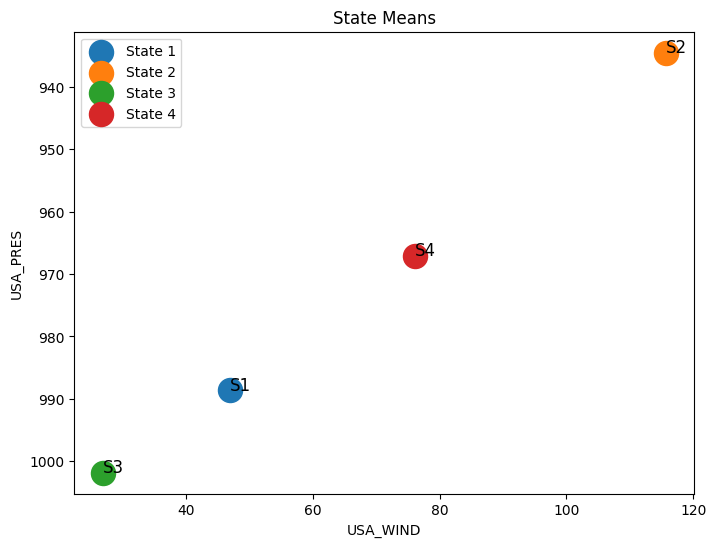

In [327]:
plot_state_means(
    state_summary,
    "USA_WIND",
    "USA_PRES",
    "State Means"
)

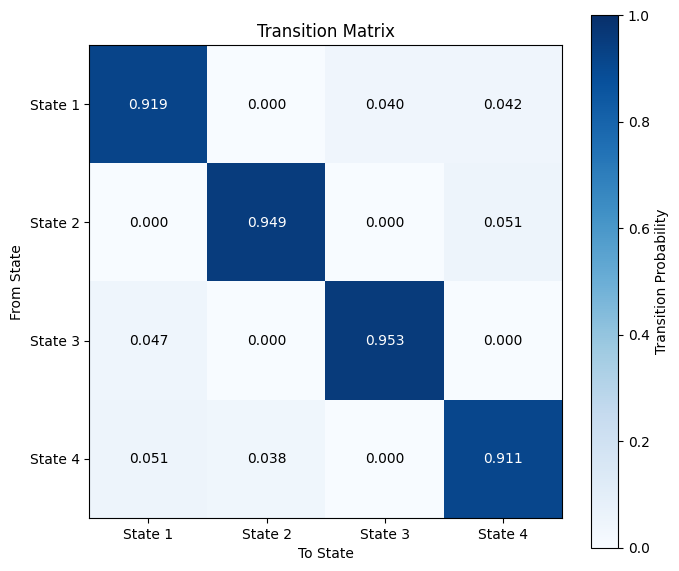

In [328]:
plot_transition_matrix(model)

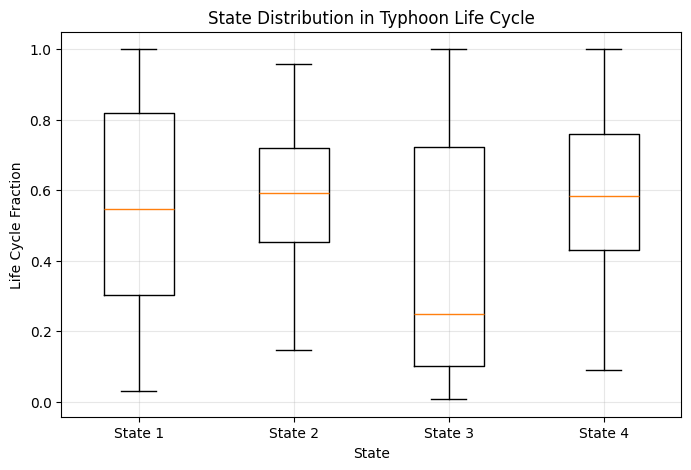

In [329]:
plot_life_cycle_boxplot(
    df=df_hmm,
    label_col="STATE",
    label_name="State",
    title="State Distribution in Typhoon Life Cycle"
)

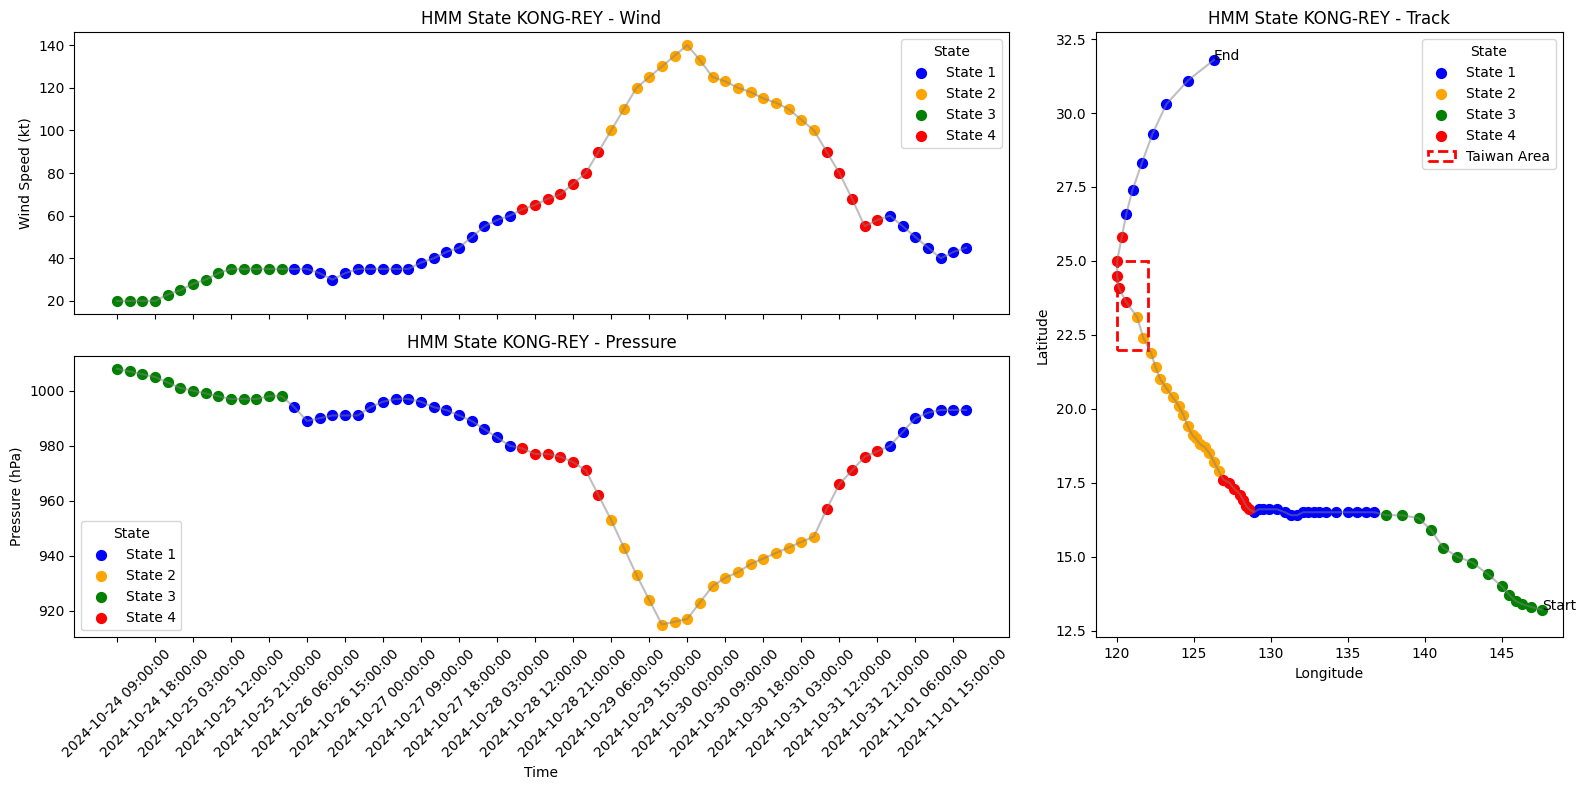

In [330]:
plot_typhoon_states(
    df_hmm,
    sid,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

> 這個結果和傳統用風速區分颱風強度的感覺很像，但無法展現颱風的生命週期（例如是剛形成，還是準備消散）

### HMM using Wind, Pressure, dWind, dPressure Information

In [370]:
features = [
    "USA_WIND",
    "USA_PRES",
    "dWind",
    "dPres"
]

X_raw = df_hmm[features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [371]:
lengths = (
    df_hmm
    .groupby("SID")
    .size()
    .tolist()
)

# Filter out typhoons with fewer than 4 observations
valid_sid = (
    df_hmm.groupby("SID")
    .size()
    .loc[lambda x: x >= 4]
    .index
)

df_hmm = df_hmm[df_hmm["SID"].isin(valid_sid)].copy()

X_raw = df_hmm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X = X_scaled.values
lengths = df_hmm.groupby("SID").size().tolist()

In [372]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -58151.45272121             +nan
         2  -35999.92790480  +22151.52481641
         3  -34625.49276390   +1374.43514090
         4  -33769.94421550    +855.54854840
         5  -33176.32414950    +593.62006600
         6  -32622.83090925    +553.49324026
         7  -32280.12136372    +342.70954552
         8  -32005.40357529    +274.71778843
         9  -31729.82096634    +275.58260896
        10  -31441.61002496    +288.21094138
        11  -31070.33091187    +371.27911309
        12  -30584.00198058    +486.32893129
        13  -30352.05673850    +231.94524208
        14  -30237.57901720    +114.47772129
        15  -30135.40924519    +102.16977201
        16  -30010.07515402    +125.33409117
        17  -29867.72470055    +142.35045347
        18  -29728.99218418    +138.73251637
        19  -29607.17233721    +121.81984697
        20  -29502.60700289    +104.56533431
        21  -29418.30908865     +84.29791424
        22  -29338.64960688     +79.65948177
        23

In [373]:
df_hmm["STATE_ID"] = df_hmm["STATE"] + 1

state_summary = (
    df_hmm
   .groupby("STATE_ID")[features]
    .mean()
)

print(state_summary)

            USA_WIND     USA_PRES     dWind     dPres
STATE_ID                                             
1          51.562603   984.484349 -4.672982  3.443987
2          26.733496  1001.849407  0.552175 -0.306967
3          49.725780   986.759852  1.587438 -1.155993
4         100.885147   946.885502  0.554059 -0.516484


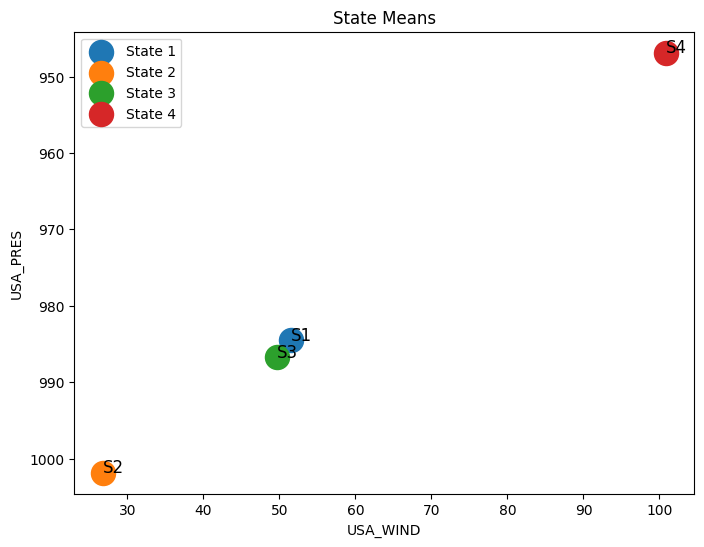

In [374]:
plot_state_means(
    state_summary,
    "USA_WIND",
    "USA_PRES",
    "State Means"
)

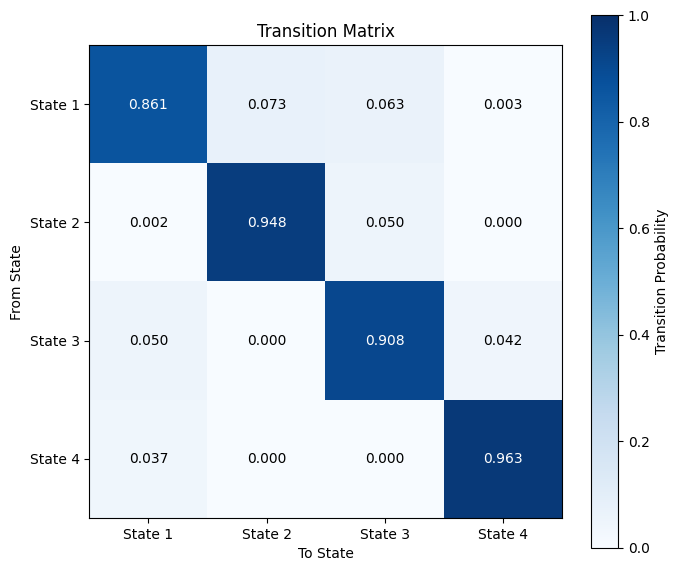

In [375]:
plot_transition_matrix(model)

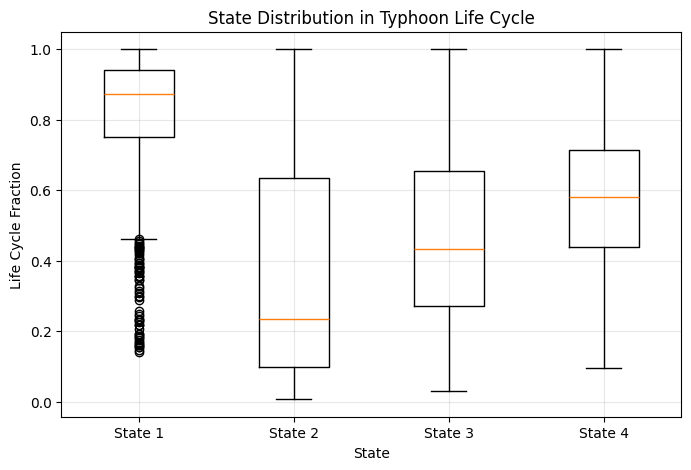

In [376]:
plot_life_cycle_boxplot(
    df=df_hmm,
    label_col="STATE",
    label_name="State",
    title="State Distribution in Typhoon Life Cycle"
)

> 能看出state在整個颱風生命週期中是有出現順序的

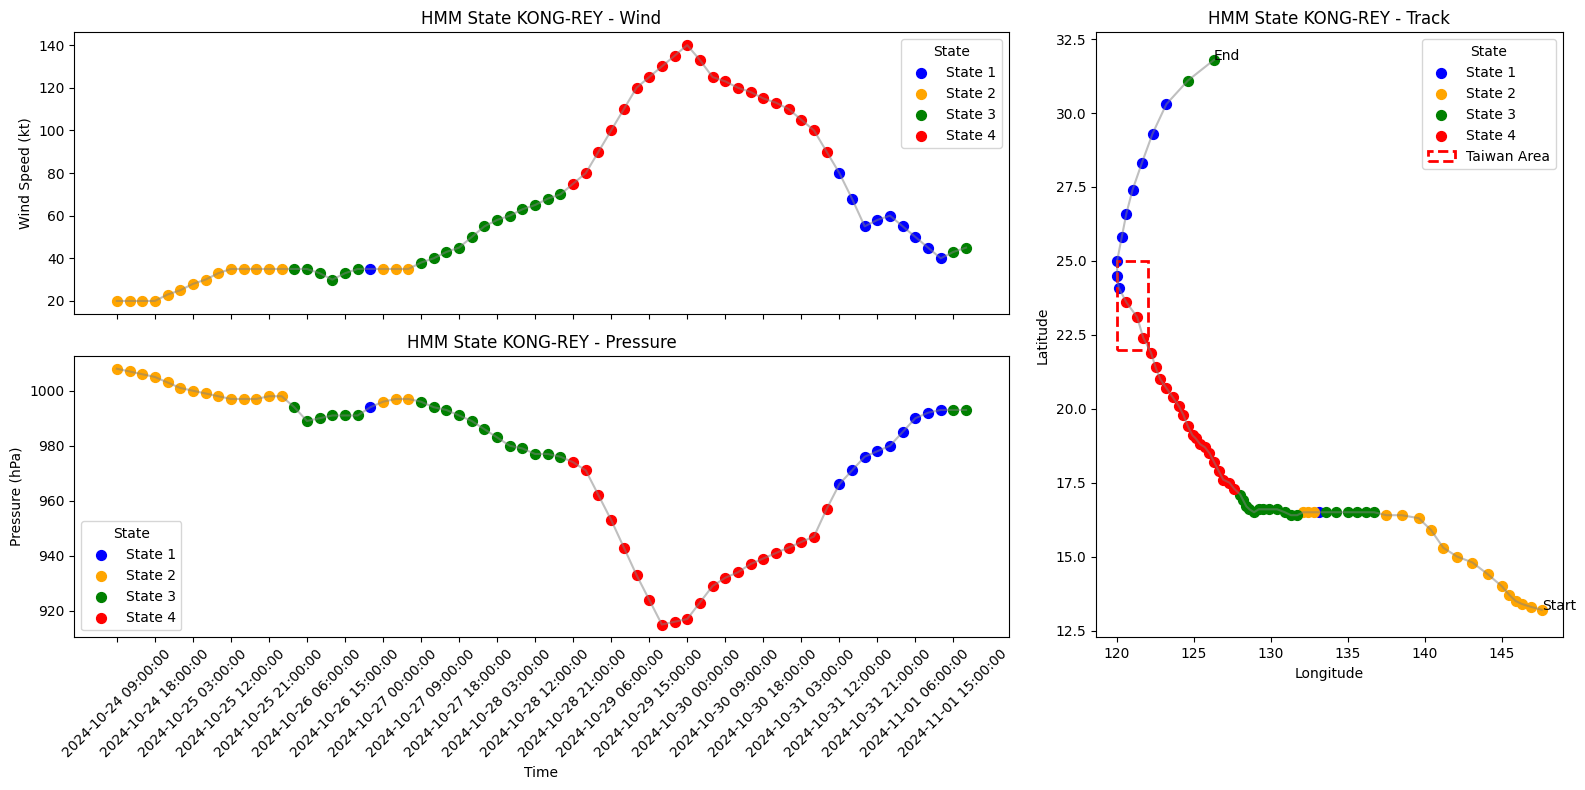

In [377]:
plot_typhoon_states(
    df_hmm,
    sid,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

In [ ]:
sid1 = "2016265N10150" #MEGI

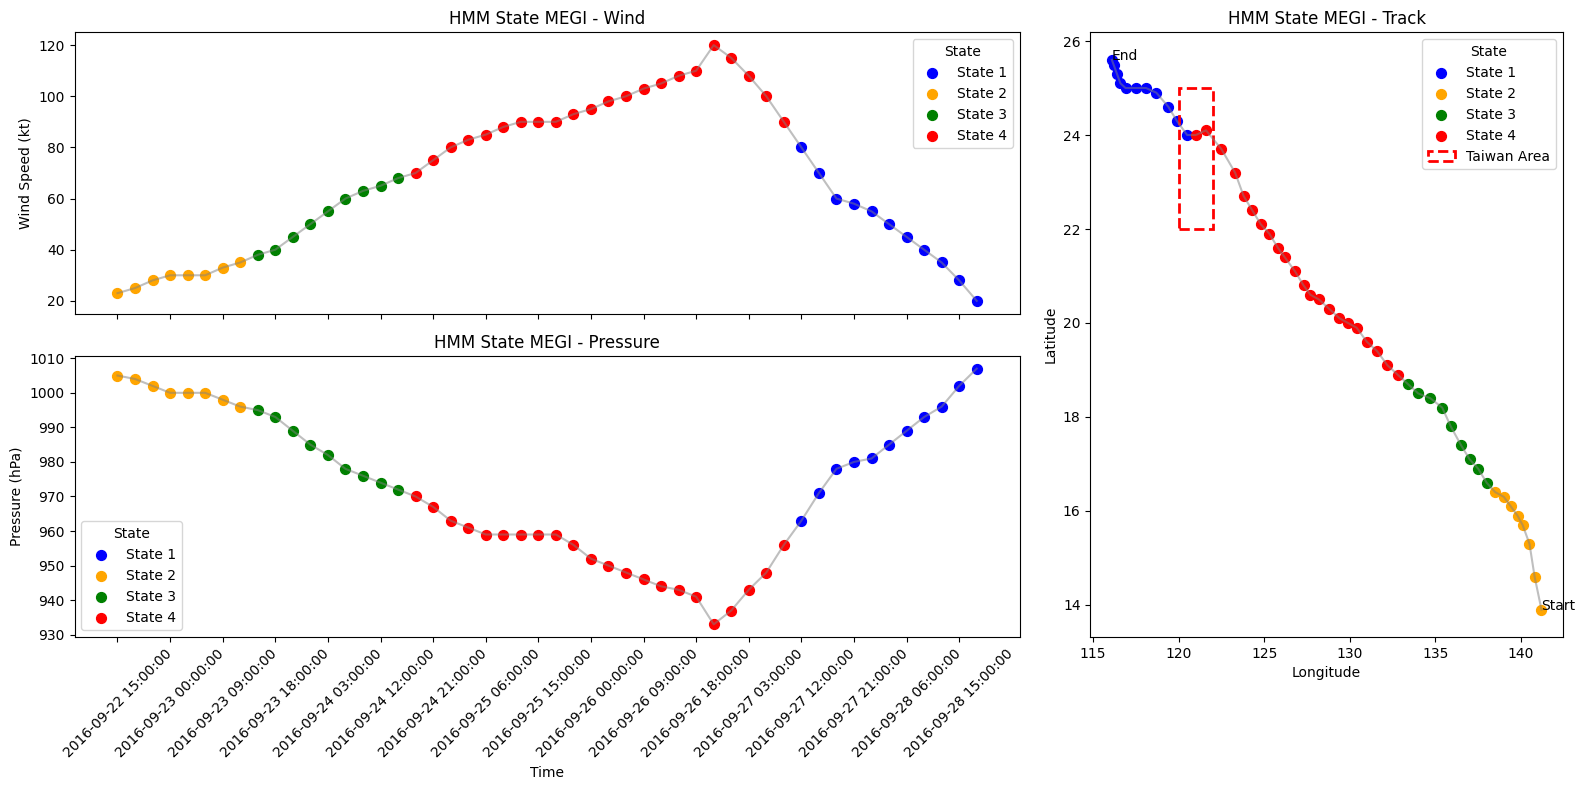

In [382]:
plot_typhoon_states(
    df_hmm,
    sid1,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

In [ ]:
sid2 = "2016185N08145" #NEPARTAK

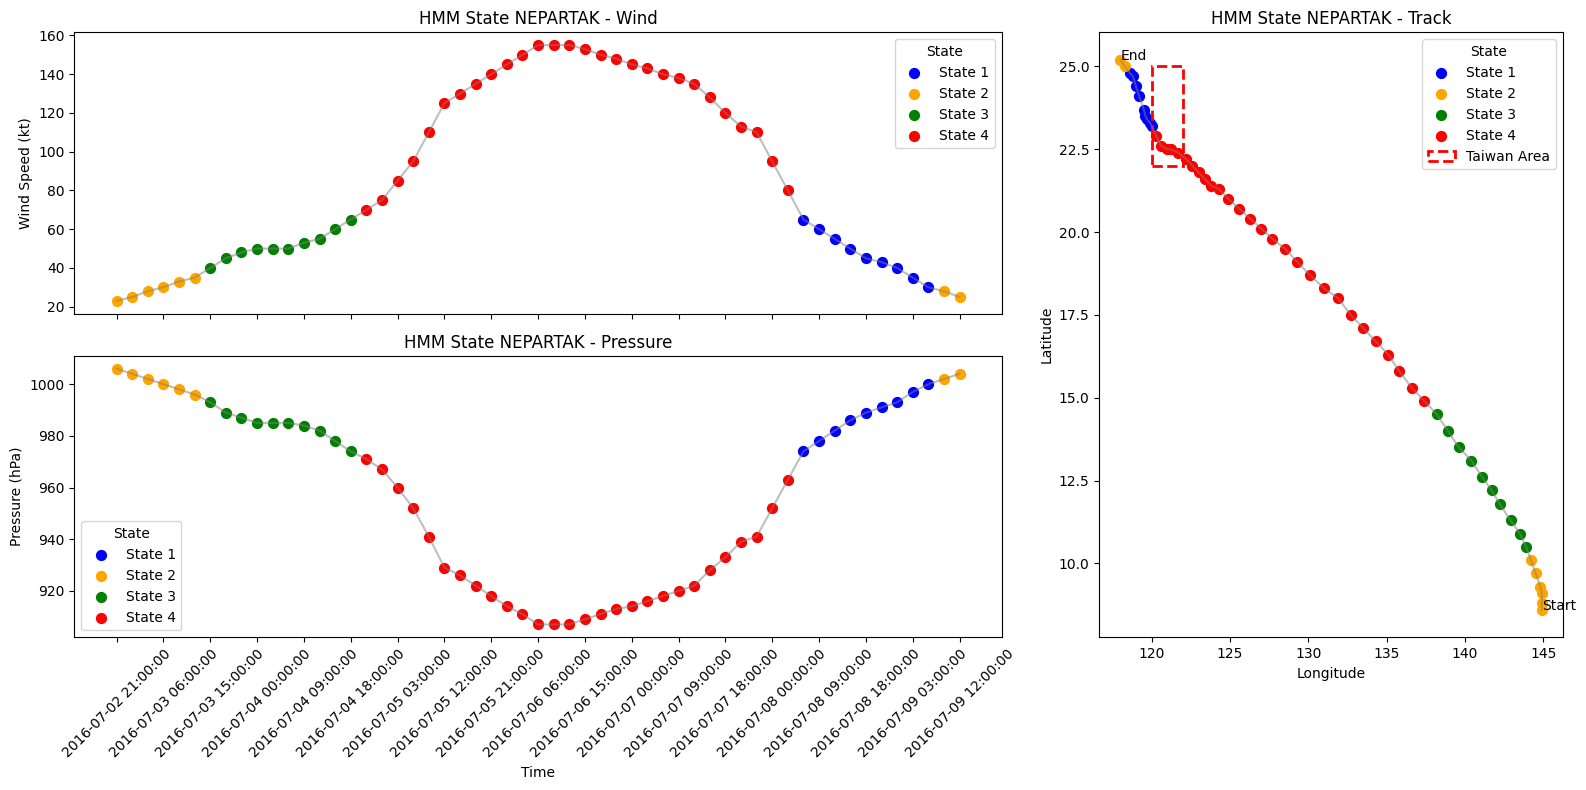

In [387]:
plot_typhoon_states(
    df_hmm,
    sid2,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

In [393]:
sid3 = "2015263N14148" #DUJUAN

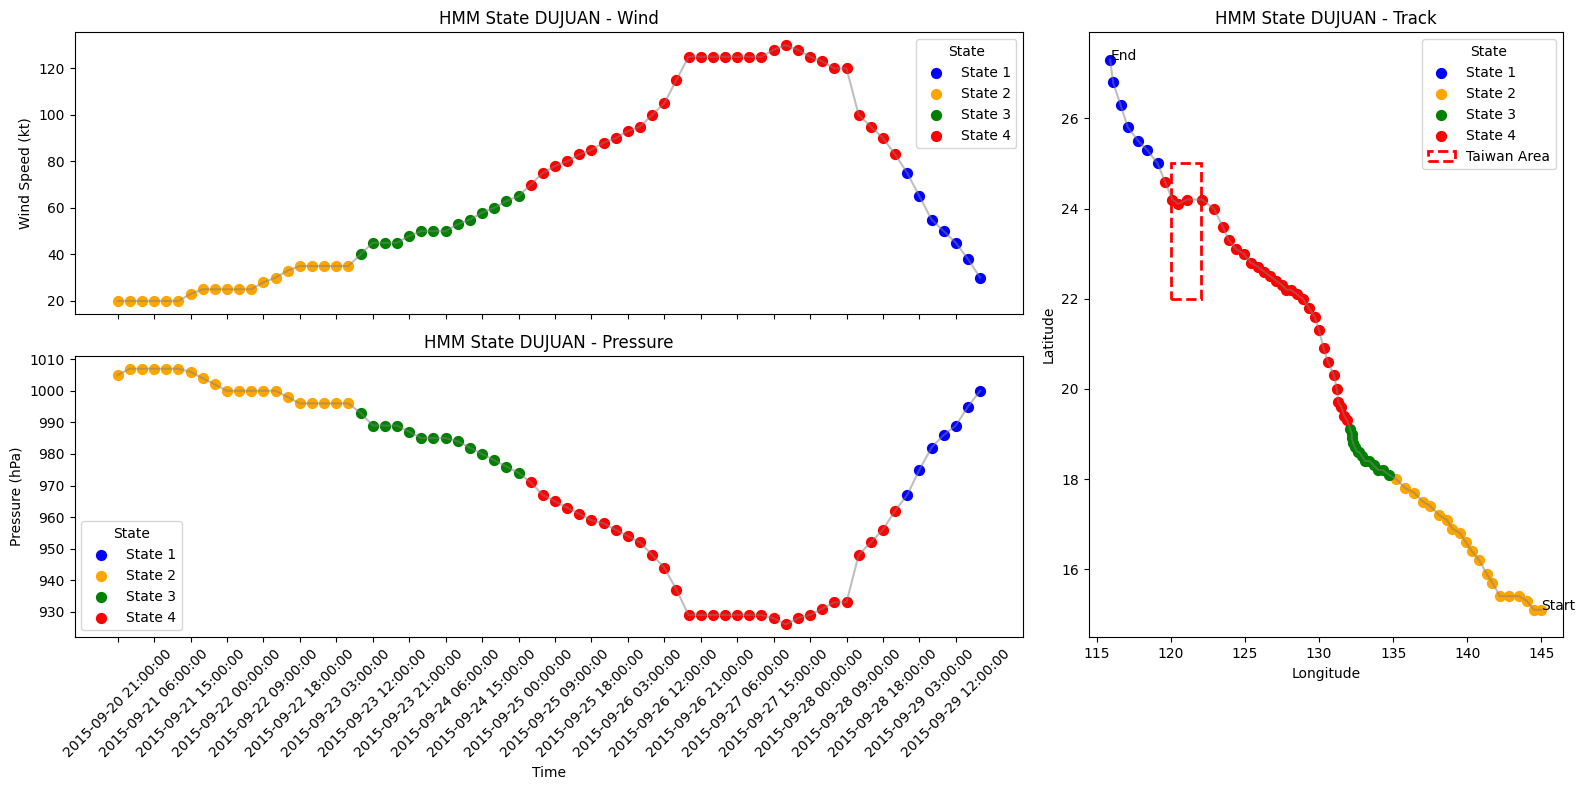

In [394]:
plot_typhoon_states(
    df_hmm,
    sid3,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

### Special Case

In [408]:
sid4 = "2025184N20122" #DANAS

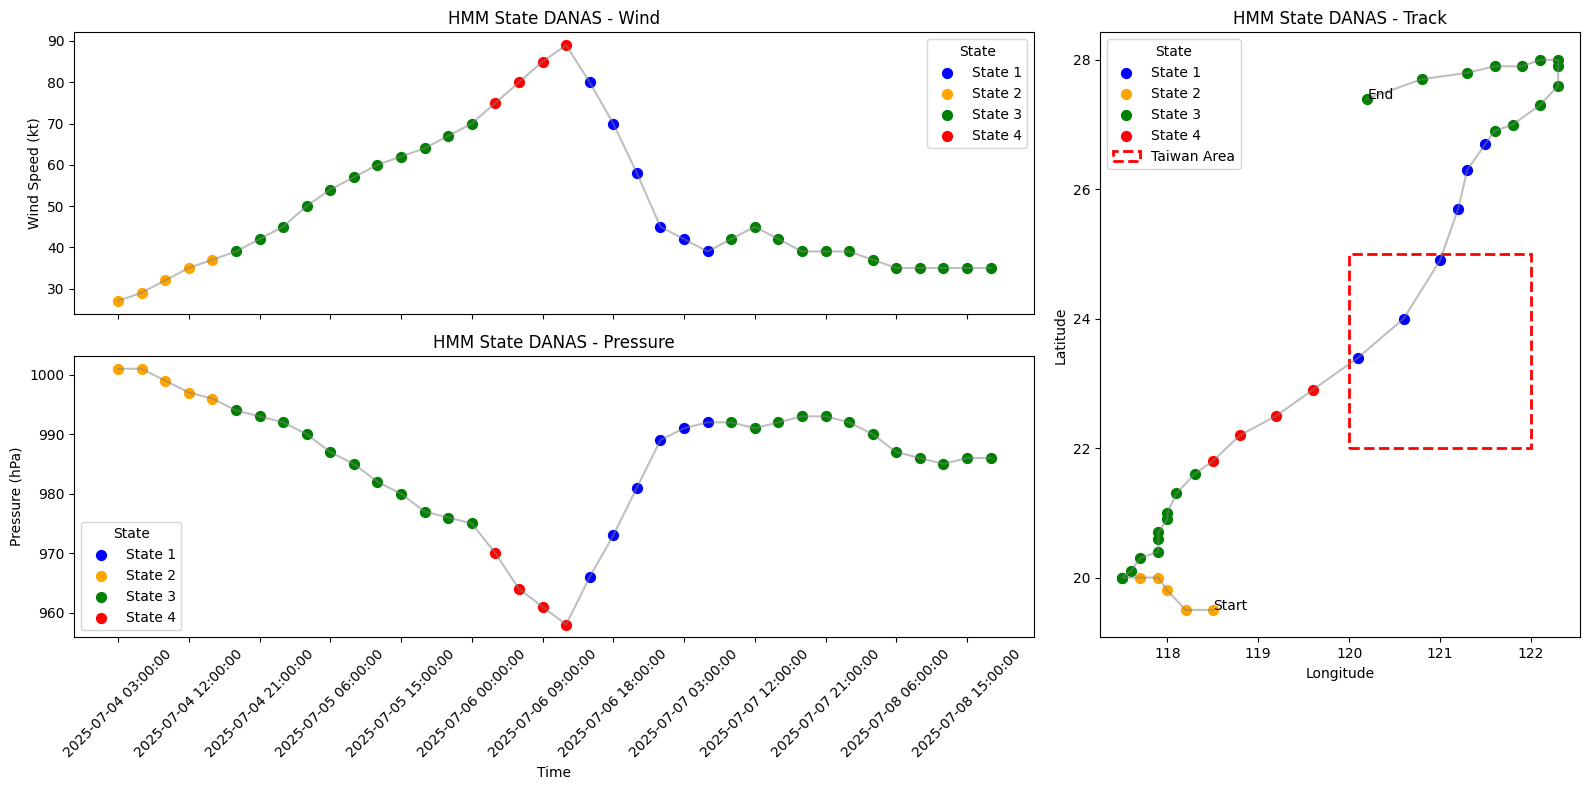

In [409]:
plot_typhoon_states(
    df_hmm,
    sid4,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

In [ ]:
sid5 = "2001248N23125" #NARI

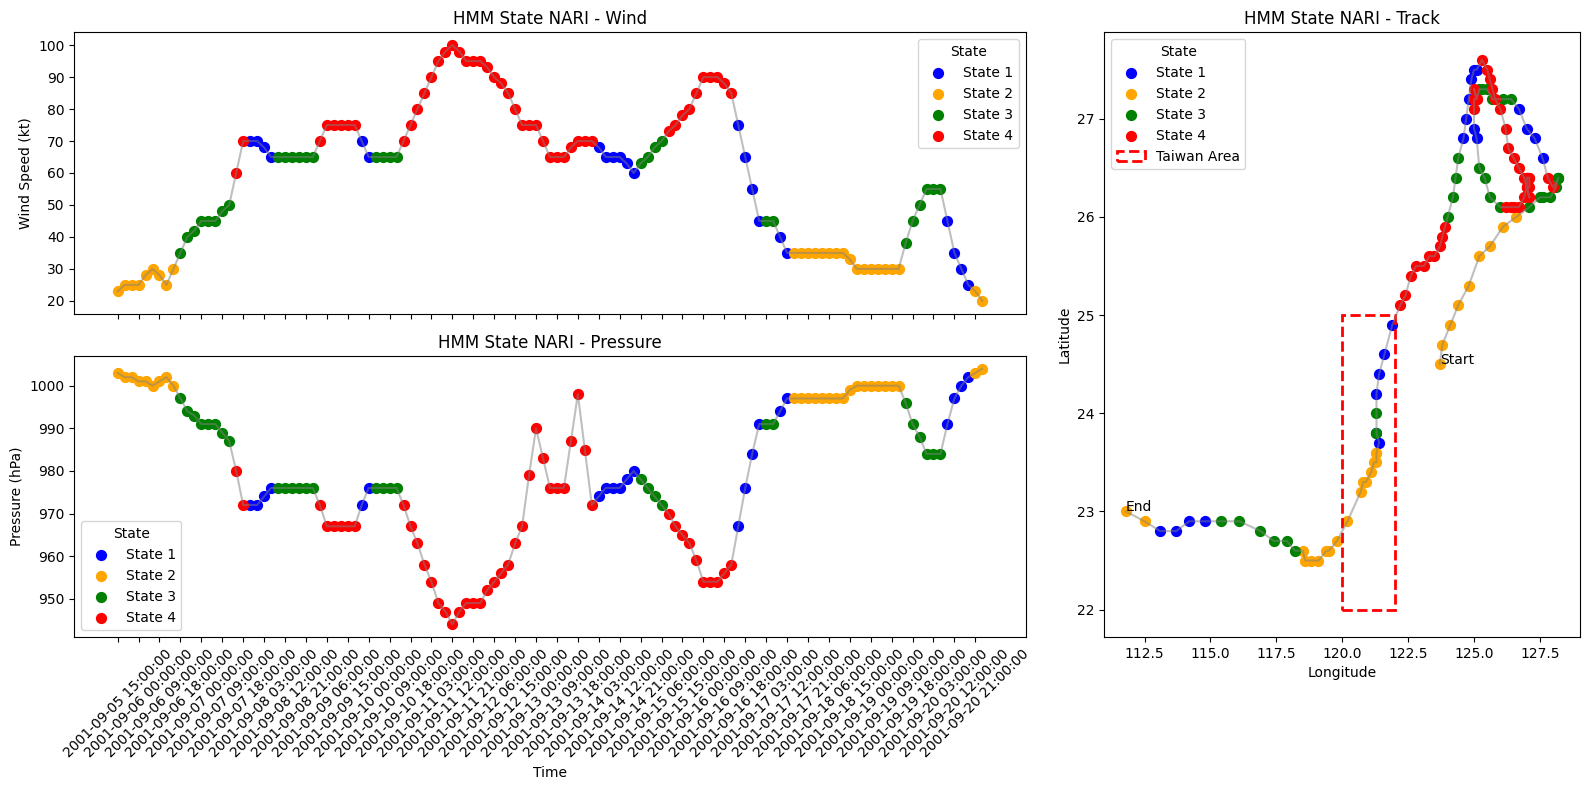

In [413]:
plot_typhoon_states(
    df_hmm,
    sid5,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

In [ ]:
sid6 = "2012230N21126" #TEMBIN

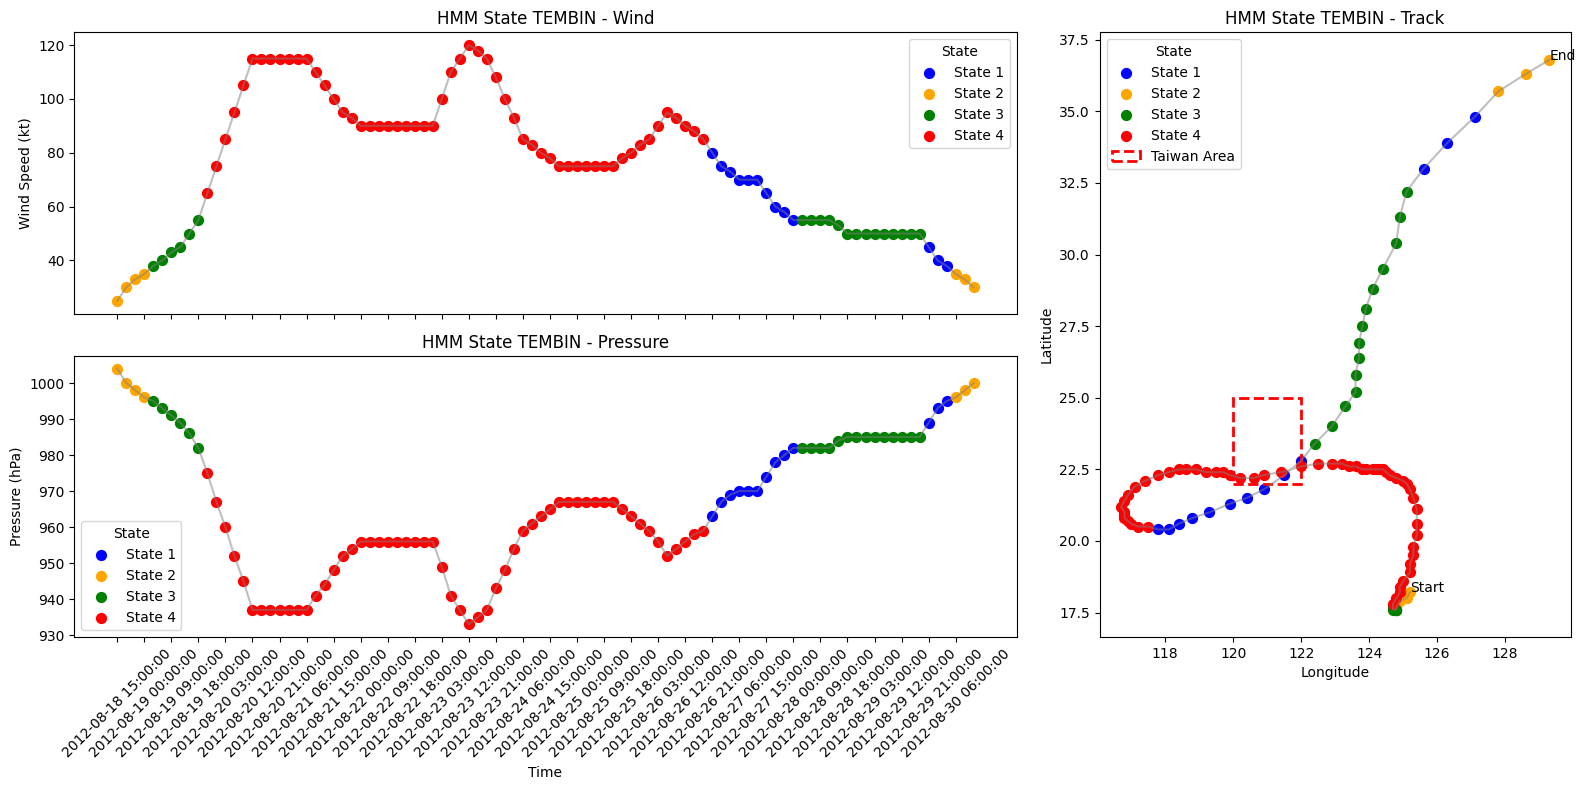

In [423]:
plot_typhoon_states(
    df_hmm,
    sid6,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

> state已經可以展現出是颱風剛形成還是快要消散

> 且可以看到經過台灣後，進入另一個state(符合進入陸地會開始減弱的認知)

#### Why covariance_type change to diag?

> If use covariance_type=full

In [339]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -35719.58830183             +nan
         2  -20961.27592856  +14758.31237327
         3  -18644.43940652   +2316.83652204
         4  -17192.81225746   +1451.62714906
         5  -16128.14093362   +1064.67132383
         6  -15563.31334680    +564.82758683
         7  -15187.41765097    +375.89569583
         8  -14835.33423627    +352.08341470
         9  -14479.26836810    +356.06586817
        10  -14124.85526994    +354.41309816
        11  -13746.97232119    +377.88294876
        12  -13310.98483818    +435.98748300
        13  -12820.72393583    +490.26090235
        14  -12388.13530334    +432.58863250
        15  -12053.02532361    +335.10997972
        16  -11849.55205640    +203.47326721
        17  -11747.89426659    +101.65778981
        18  -11691.68810986     +56.20615673
        19  -11644.88957688     +46.79853298
        20  -11601.69268107     +43.19689580
        21  -11545.87364500     +55.81903607
        22  -11448.51112670     +97.36251831
        23

In [340]:
df_hmm["STATE_ID"] = df_hmm["STATE"] + 1

state_summary = (
    df_hmm
   .groupby("STATE_ID")[features]
    .mean()
)

print(state_summary)

           USA_WIND     USA_PRES     dWind     dPres
STATE_ID                                            
1         73.307159   968.121622 -0.099708  0.060628
2         27.295309  1001.388795  0.761728 -0.420182
3         49.990771   989.163409  0.565147 -0.425081
4         82.404063   958.592777 -0.655982  0.343567


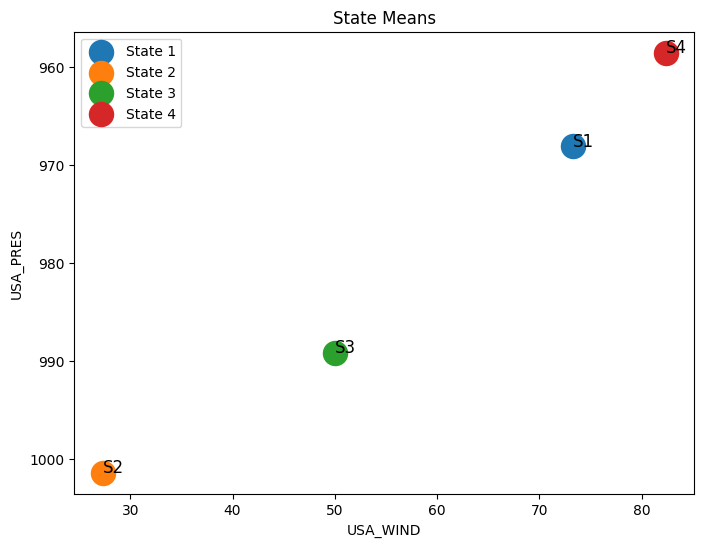

In [341]:
plot_state_means(
    state_summary,
    "USA_WIND",
    "USA_PRES",
    "State Means"
)

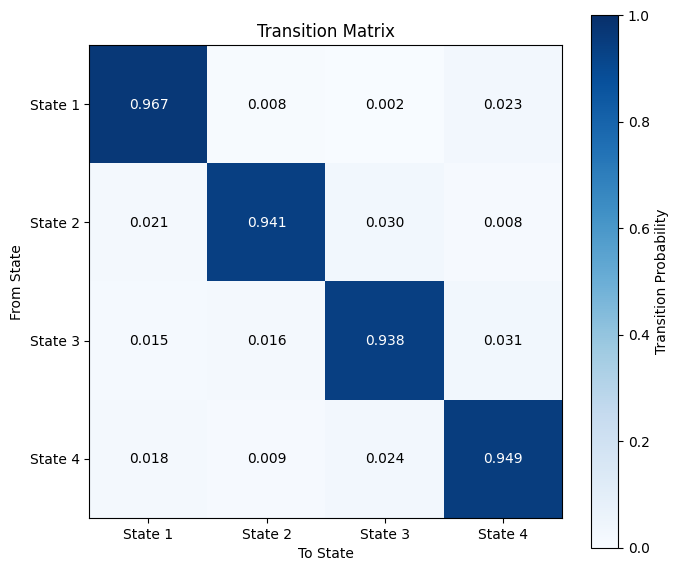

In [342]:
plot_transition_matrix(model)

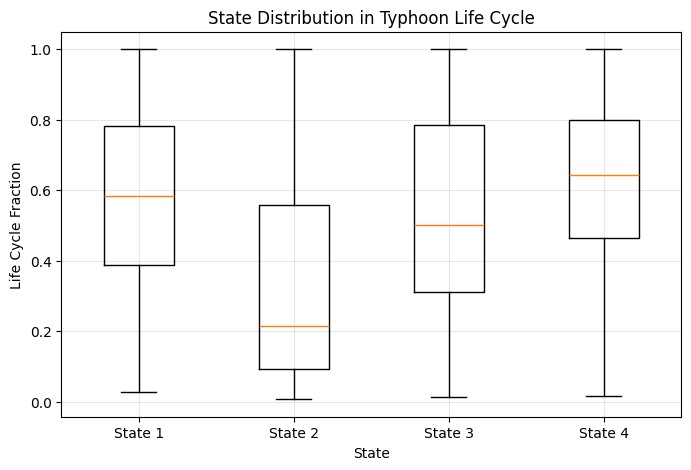

In [343]:
plot_life_cycle_boxplot(
    df=df_hmm,
    label_col="STATE",
    label_name="State",
    title="State Distribution in Typhoon Life Cycle"
)

>  相較於diag比較沒有那麼強的順序性

1. 因為Wind 和 Pressure 天生高度相關，full會讓模型過度聚焦於這兩個特徵

2. 因為full有相互參照，會讓參數翻倍，當樣本數不夠多的時候很容易overfitting

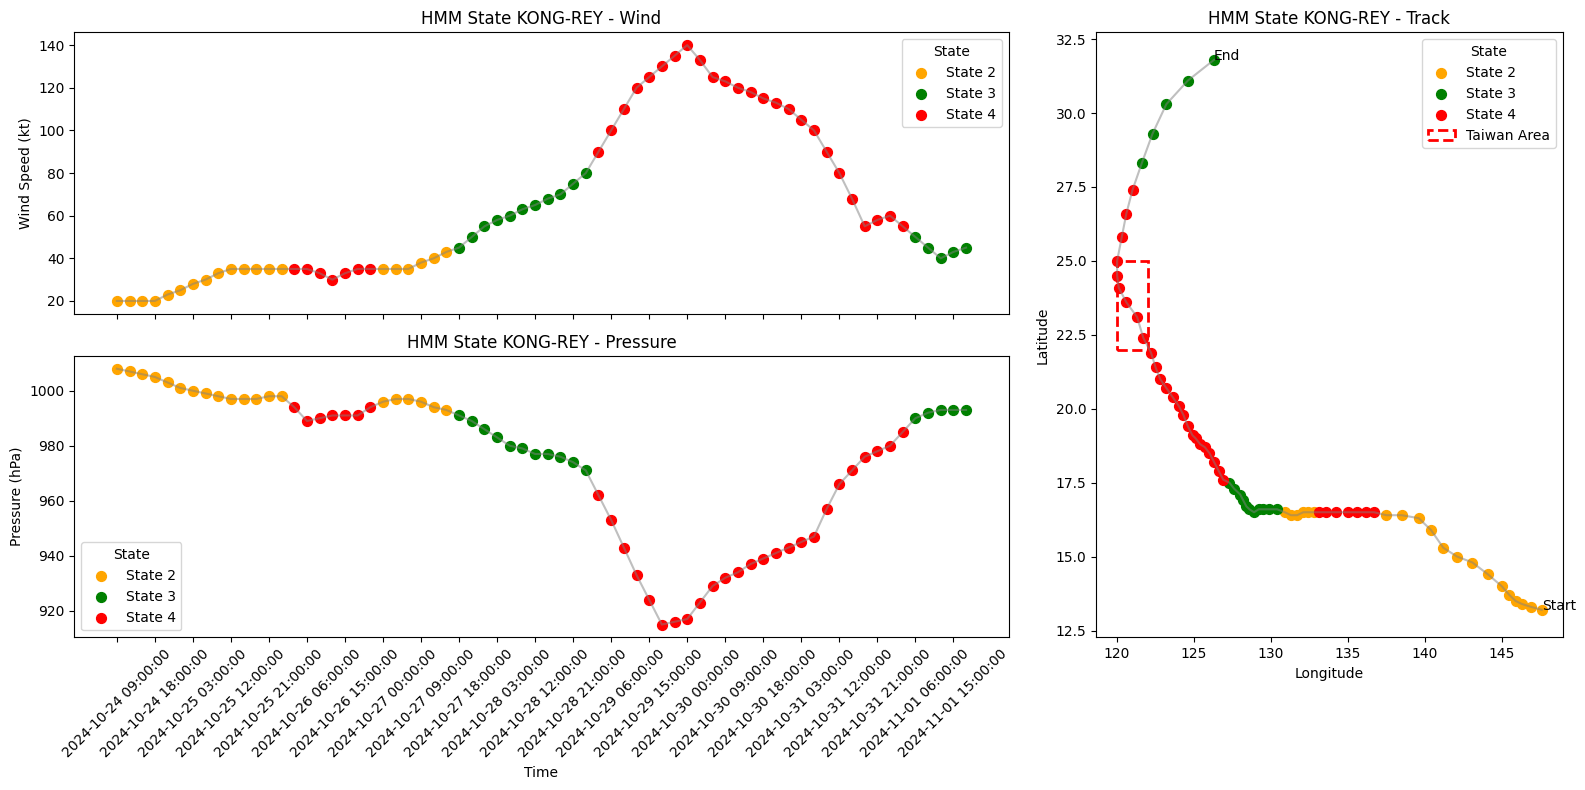

In [344]:
plot_typhoon_states(
    df_hmm,
    sid,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)

#### Why State is 4?

If we use state=5

In [345]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=5,
    covariance_type="diag",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -59980.54071345             +nan
         2  -43052.29480160  +16928.24591185
         3  -37398.64291440   +5653.65188720
         4  -35509.52092648   +1889.12198792
         5  -34746.26537598    +763.25555050
         6  -33488.05273177   +1258.21264420
         7  -31460.45323041   +2027.59950137
         8  -30593.62710449    +866.82612592
         9  -30345.05206313    +248.57504136
        10  -30170.68369189    +174.36837123
        11  -30008.84481098    +161.83888092
        12  -29844.12807818    +164.71673279
        13  -29679.95230588    +164.17577230
        14  -29544.04659855    +135.90570733
        15  -29440.26504688    +103.78155166
        16  -29355.24768425     +85.01736264
        17  -29279.70586042     +75.54182383
        18  -29204.57009211     +75.13576831
        19  -29148.29394702     +56.27614509
        20  -29120.12608243     +28.16786459
        21  -29100.74425906     +19.38182337
        22  -29082.97964477     +17.76461429
        23

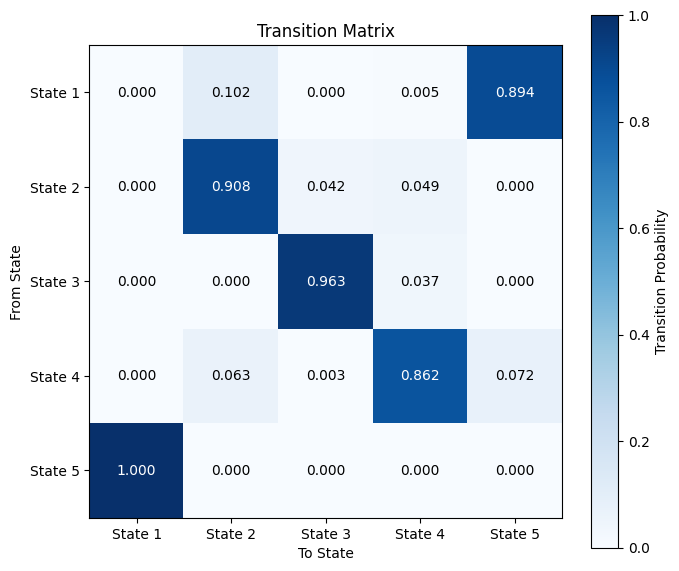

In [346]:
plot_transition_matrix(model)

> In the five-state model, the additional state mainly behaves as a transient state. It almost always transitions back to State 1 and does not represent a stable physical regime. Therefore, the five-state model appears to fragment one regime rather than reveal a new meaningful typhoon stage.

If we use state=3

In [347]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -61661.49814964             +nan
         2  -49857.71428996  +11803.78385968
         3  -48393.78712999   +1463.92715996
         4  -43647.84663833   +4745.94049166
         5  -39586.56092524   +4061.28571309
         6  -38632.82140201    +953.73952324
         7  -38392.60279027    +240.21861174
         8  -38311.91378046     +80.68900981
         9  -38277.41280537     +34.50097510
        10  -38260.16658249     +17.24622287
        11  -38252.42627343      +7.74030906
        12  -38249.11825808      +3.30801536
        13  -38247.46147630      +1.65678178
        14  -38246.44268841      +1.01878789
        15  -38245.64419554      +0.79849287
        16  -38244.88499131      +0.75920423
        17  -38244.08327152      +0.80171979
        18  -38243.19379737      +0.88947415
        19  -38242.18007675      +1.01372062
        20  -38241.00183001      +1.17824675
        21  -38239.60873420      +1.39309581
        22  -38237.93721804      +1.67151615
        23

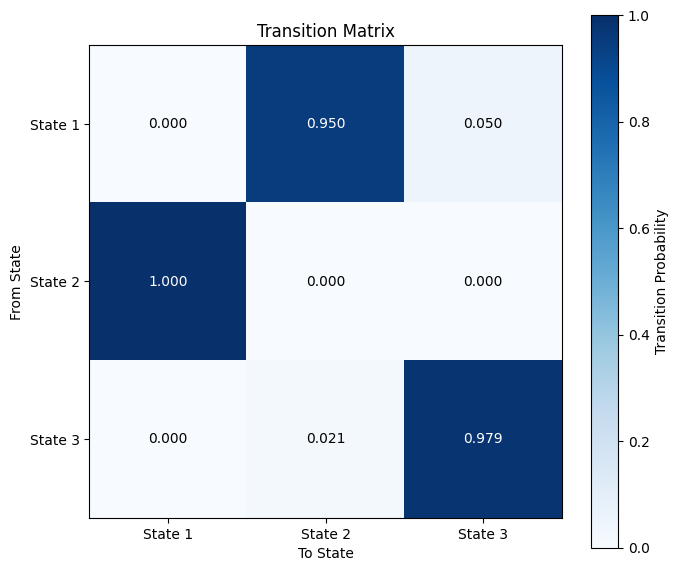

In [348]:
plot_transition_matrix(model)

> In the three-state model, State 1 and State 2 formed a strong alternating transition pattern, while State 3 became highly persistent. This suggests that the model may not have sufficient state capacity to distinguish all phases of typhoon evolution, causing some regimes to be merged into a single state.

### 還可以比較多個經典颱風（不要只有單一例子）

### HMM using Wind, Pressure, dWind, dPressure, and life_frac (not good to use)

In [271]:
features = [
    "USA_WIND",
    "USA_PRES",
    "dWind",
    "dPres",
    "life_frac",
]

X_raw = df_hmm[features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [272]:
lengths = (
    df_hmm
    .groupby("SID")
    .size()
    .tolist()
)

# Filter out typhoons with fewer than 4 observations
valid_sid = (
    df_hmm.groupby("SID")
    .size()
    .loc[lambda x: x >= 4]
    .index
)

df_hmm = df_hmm[df_hmm["SID"].isin(valid_sid)].copy()

X_raw = df_hmm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X = X_scaled.values
lengths = df_hmm.groupby("SID").size().tolist()

In [273]:
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=4,
    covariance_type="diag",
    n_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X, lengths)

df_hmm["STATE"] = model.predict(X, lengths)

         1  -68913.54962803             +nan
         2  -49790.91501198  +19122.63461605
         3  -44797.53311827   +4993.38189370
         4  -43028.12958349   +1769.40353478
         5  -42143.66439530    +884.46518819
         6  -41690.23829389    +453.42610141
         7  -41543.63474680    +146.60354709
         8  -41495.31306564     +48.32168116
         9  -41470.27407312     +25.03899252
        10  -41452.94453184     +17.32954128
        11  -41441.47722072     +11.46731112
        12  -41433.59303410      +7.88418662
        13  -41427.63956974      +5.95346436
        14  -41423.25310891      +4.38646083
        15  -41420.11180046      +3.14130845
        16  -41417.70848585      +2.40331461
        17  -41415.52827669      +2.18020916
        18  -41413.06962199      +2.45865470
        19  -41410.22313798      +2.84648401
        20  -41407.53656924      +2.68656874
        21  -41405.03335981      +2.50320943
        22  -41402.03585091      +2.99750890
        23

In [274]:
df_hmm["STATE_ID"] = df_hmm["STATE"] + 1

state_summary = (
    df_hmm
   .groupby("STATE_ID")[features]
    .mean()
)

print(state_summary)

            USA_WIND     USA_PRES     dWind     dPres  life_frac
STATE_ID                                                        
1         100.473025   947.197007  0.031326 -0.097807   0.592716
2          27.024363  1001.940405  1.040855 -0.544228   0.212354
3          40.322535   992.031455 -2.352113  1.546009   0.874846
4          52.492573   984.979875  1.780067 -1.275036   0.397530


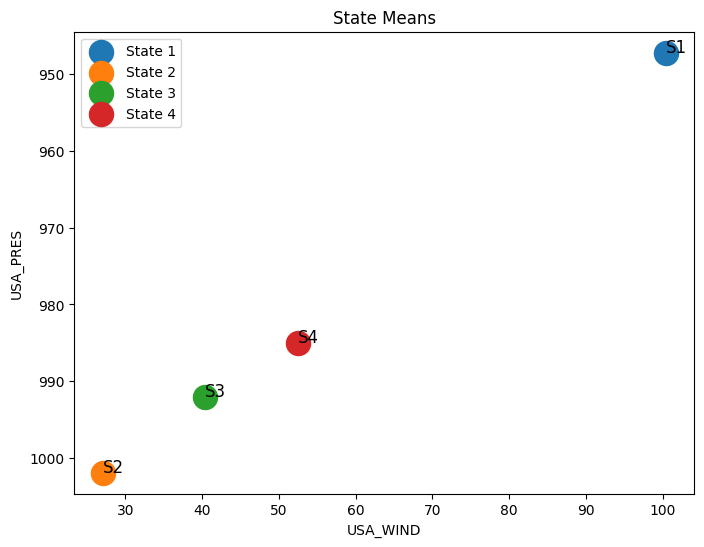

In [275]:
plot_state_means(
    state_summary,
    "USA_WIND",
    "USA_PRES",
    "State Means"
)

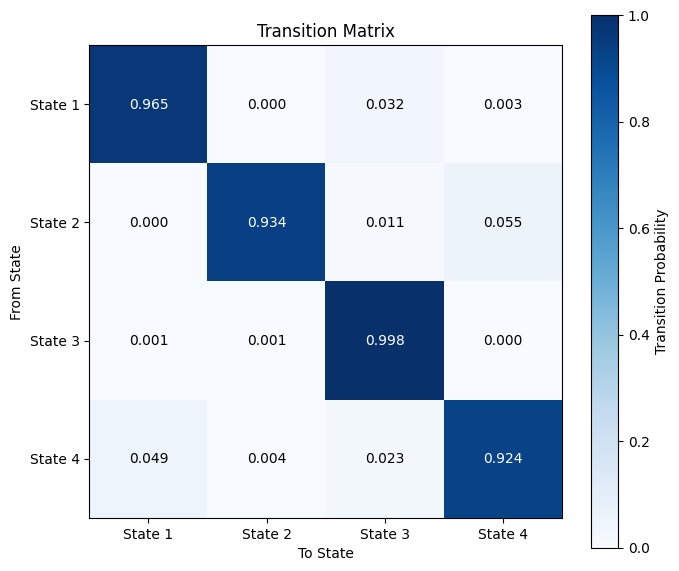

In [277]:
plot_transition_matrix(model)

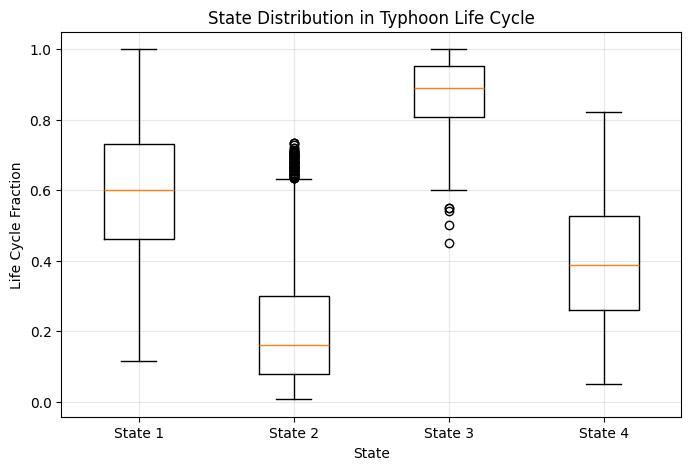

In [278]:
plot_life_cycle_boxplot(
    df=df_hmm,
    label_col="STATE",
    label_name="State",
    title="State Distribution in Typhoon Life Cycle"
)

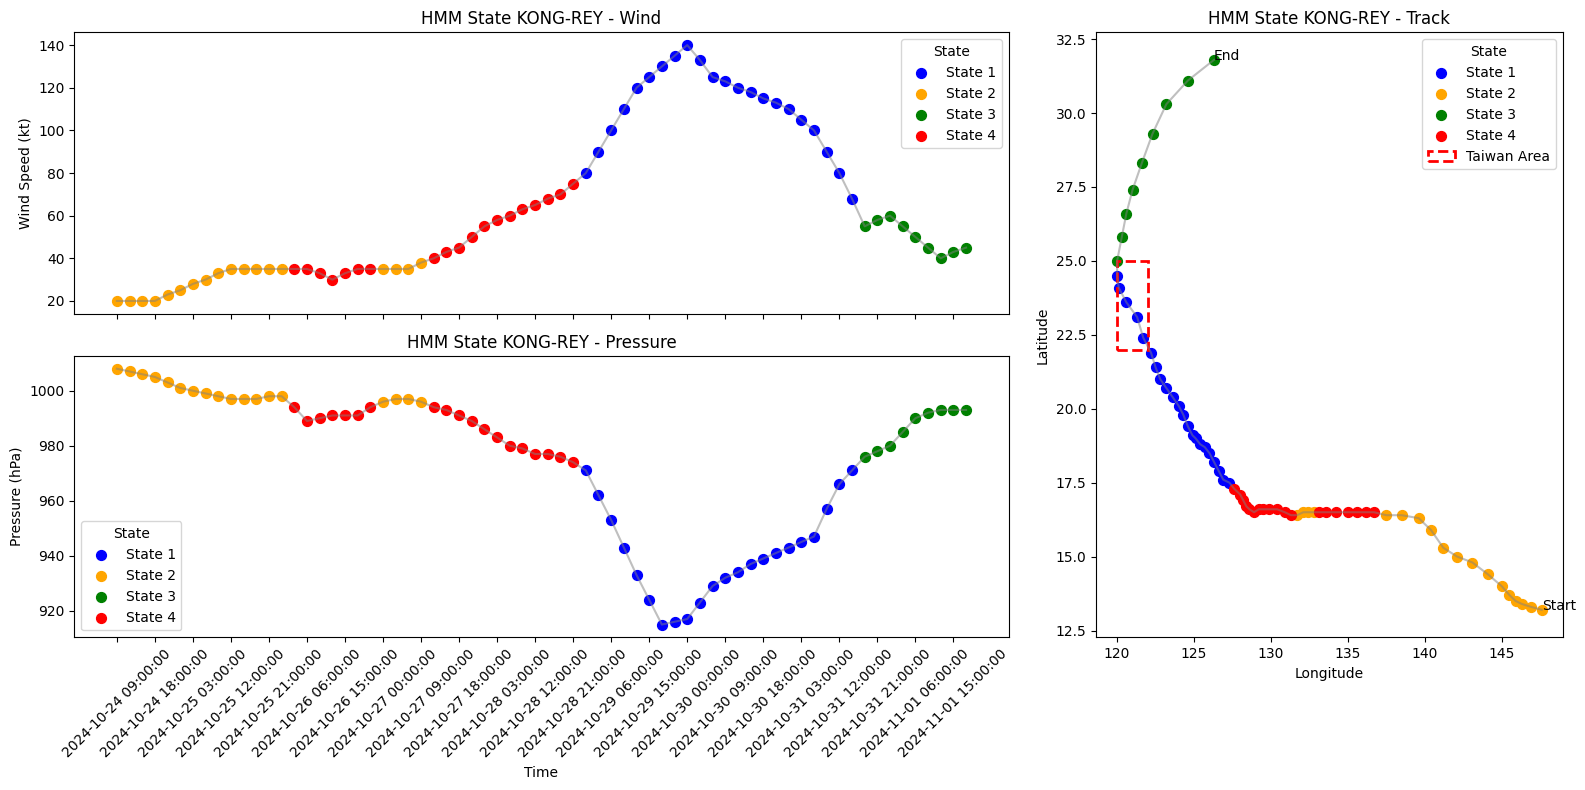

In [279]:
plot_typhoon_states(
    df_hmm,
    sid,
    label_col="STATE",
    label_name="State",
    title_prefix="HMM State"
)